## Datos
Carga y descripción del dataset.

In [28]:
!pip install seaborn


[notice] A new release of pip is available: 25.0.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [29]:
# Importaciones necesarias
from pymongo import MongoClient
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración de visualización
sns.set_theme()  # Configura el estilo de seaborn
sns.set_palette('husl')
%matplotlib inline

In [30]:
# Conexión a MongoDB
client = MongoClient("mongodb://localhost:27017/")
db = client['trafico']
videos_col = db['Videos']
frames_col = db['VideosFrames']

## 1. Listar Videos Disponibles

In [31]:
for video in videos_col.find():
    print(f"ID: {video['_id']}")
    print(f"Nombre: {video['nombre']}")
    print(f"Fecha: {video['fecha_subida']}")
    print(f"Descripción: {video.get('descripcion', 'Sin descripción')}")
    print("-" * 50)

ID: 6847bb810270edd78fabb649
Nombre: tradffic7.mp4
Fecha: 2025-06-09 22:58:41.913000
Descripción: Video de tráfico urbano
--------------------------------------------------
ID: 6847bd7d0270edd78fabb67a
Nombre: tradffic8.mp4
Fecha: 2025-06-09 23:07:09.742000
Descripción: Video de tráfico urbano
--------------------------------------------------
ID: 6847bf080270edd78fabbd82
Nombre: tradffic1.mp4
Fecha: 2025-06-09 23:13:44.264000
Descripción: Video de tráfico urbano
--------------------------------------------------
ID: 6847bf1e0270edd78fabbd86
Nombre: tradffic1.mp4
Fecha: 2025-06-09 23:14:06.204000
Descripción: Video de tráfico urbano
--------------------------------------------------
ID: 6847bf3c0270edd78fabbd8a
Nombre: tradffic1.mp4
Fecha: 2025-06-09 23:14:35.959000
Descripción: Video de tráfico urbano
--------------------------------------------------
ID: 6847bf700270edd78fabbd8e
Nombre: tradffic2.mp4
Fecha: 2025-06-09 23:15:28.059000
Descripción: Video de tráfico urbano
-------------

## 2. Extraer Datos a DataFrame

In [32]:
def extraer_datos_a_dataframe():
    # Obtener todos los frames
    frames = list(frames_col.find())

    # Crear DataFrame
    df = pd.DataFrame(frames)

    # Extraer métricas de la columna 'metricas'
    df['timestamp'] = df['metricas'].apply(lambda x: x.get('timestamp'))
    df['total_vehiculos'] = df['metricas'].apply(lambda x: x.get('total_vehicles', 0))
    df['densidad_trafico'] = df['metricas'].apply(lambda x: x.get('traffic_density', 0))
    df['tiempo_espera'] = df['metricas'].apply(lambda x: x.get('waiting_time', 0))

    # Extraer conteo por tipo de vehículo
    df['carros'] = df['metricas'].apply(lambda x: x.get('by_class', {}).get('car', 0))
    df['camiones'] = df['metricas'].apply(lambda x: x.get('by_class', {}).get('truck', 0))
    df['motocicletas'] = df['metricas'].apply(lambda x: x.get('by_class', {}).get('motorcycle', 0))

    return df

# Crear DataFrame

In [33]:
df = extraer_datos_a_dataframe()
print("Dimensiones del DataFrame:", df.shape)
df.head()

Dimensiones del DataFrame: (343, 13)


,_id,video_id,frame_num,gridfs_id,detecciones,metricas,timestamp,total_vehiculos,densidad_trafico,tiempo_espera,carros,camiones,motocicletas
0,6847bb820270edd78fabb64d,6847bb810270edd78fabb649,0,6847bb820270edd78fabb64a,"[{'class': 'car', 'confidence': 0.922608673572...","{'total_vehicles': 2, 'by_class': {'car': 2}, ...",2025-06-09 22:58:42.464,2,0.2,4,2,0,0
1,6847bb820270edd78fabb651,6847bb810270edd78fabb649,1,6847bb820270edd78fabb64e,"[{'class': 'car', 'confidence': 0.928321063518...","{'total_vehicles': 2, 'by_class': {'car': 2}, ...",2025-06-09 22:58:42.810,2,0.2,4,2,0,0
2,6847bb830270edd78fabb655,6847bb810270edd78fabb649,2,6847bb830270edd78fabb652,"[{'class': 'car', 'confidence': 0.924496948719...","{'total_vehicles': 3, 'by_class': {'car': 3}, ...",2025-06-09 22:58:43.123,3,0.3,6,3,0,0
3,6847bb830270edd78fabb659,6847bb810270edd78fabb649,3,6847bb830270edd78fabb656,"[{'class': 'car', 'confidence': 0.920521974563...","{'total_vehicles': 4, 'by_class': {'car': 4}, ...",2025-06-09 22:58:43.448,4,0.4,8,4,0,0
4,6847bb830270edd78fabb65d,6847bb810270edd78fabb649,4,6847bb830270edd78fabb65a,"[{'class': 'car', 'confidence': 0.927264630794...","{'total_vehicles': 3, 'by_class': {'car': 3}, ...",2025-06-09 22:58:43.772,3,0.3,6,3,0,0


## 3. Análisis Exploratorio

In [34]:
totales_vehiculos = {
    'Carros': df['carros'].sum(),
    'Camiones': df['camiones'].sum(),
    'Motocicletas': df['motocicletas'].sum()
}

# Crear gráfico de pastel

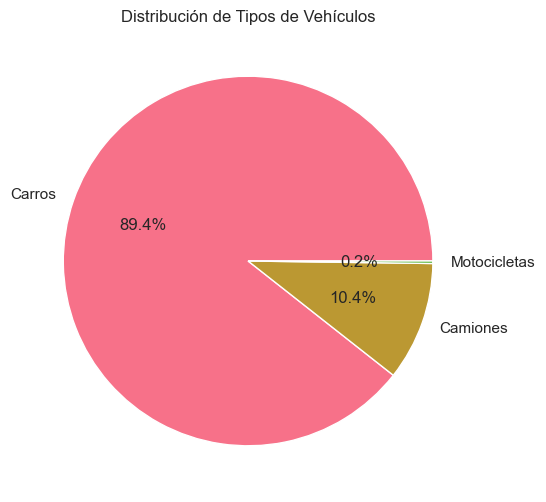

In [35]:
plt.figure(figsize=(10, 6))
plt.pie(totales_vehiculos.values(), labels=totales_vehiculos.keys(), autopct='%1.1f%%')
plt.title('Distribución de Tipos de Vehículos')
plt.show()

### 3.2 Densidad de tráfico a lo largo del tiempo

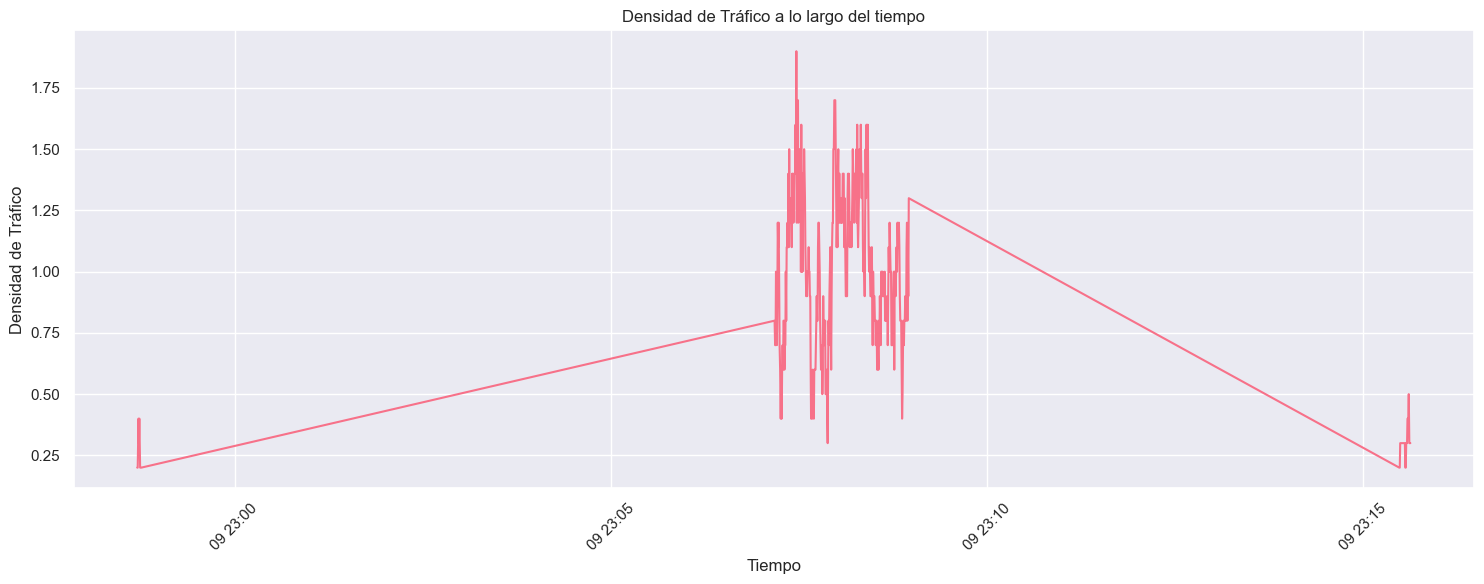

In [36]:
plt.figure(figsize=(15, 6))
plt.plot(df['timestamp'], df['densidad_trafico'])
plt.title('Densidad de Tráfico a lo largo del tiempo')
plt.xlabel('Tiempo')
plt.ylabel('Densidad de Tráfico')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Tiempos de espera

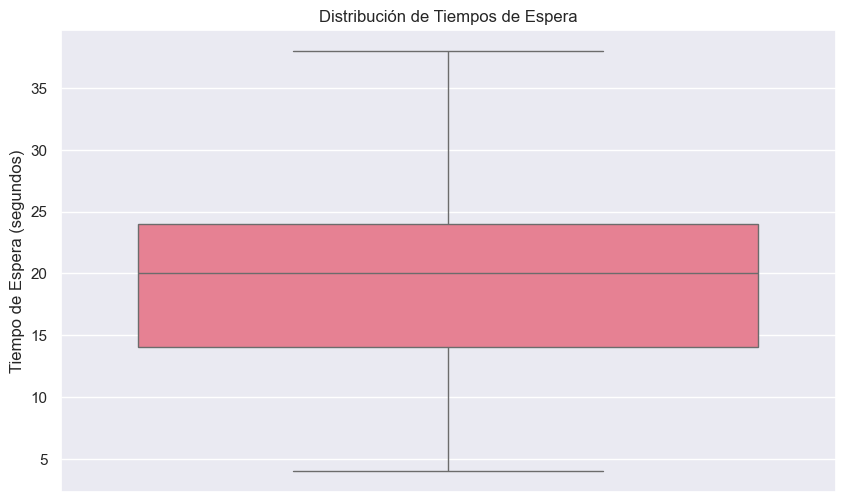

In [37]:
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, y='tiempo_espera')
plt.title('Distribución de Tiempos de Espera')
plt.ylabel('Tiempo de Espera (segundos)')
plt.show()

## 4. Estadísticas Descriptivas

In [38]:
print("\nEstadísticas Generales:")
print(df[['total_vehiculos', 'densidad_trafico', 'tiempo_espera']].describe())




Estadísticas Generales:
       total_vehiculos  densidad_trafico  tiempo_espera
count       343.000000        343.000000     343.000000
mean          9.501458          0.948105      18.962099
std           3.746245          0.372035       7.440703
min           2.000000          0.200000       4.000000
25%           7.000000          0.700000      14.000000
50%          10.000000          1.000000      20.000000
75%          12.000000          1.200000      24.000000
max          19.000000          1.900000      38.000000


# Correlaciones


Correlaciones entre métricas principales:


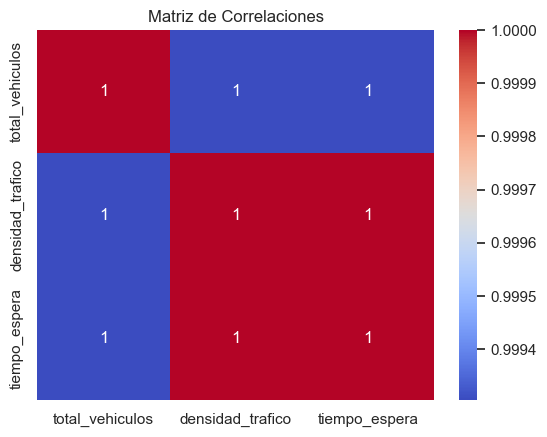

In [39]:
print("\nCorrelaciones entre métricas principales:")
correlaciones = df[['total_vehiculos', 'densidad_trafico', 'tiempo_espera']].corr()
sns.heatmap(correlaciones, annot=True, cmap='coolwarm')
plt.title('Matriz de Correlaciones')
plt.show()